<a href="https://colab.research.google.com/github/pandita56666/SPIS-ML-Seismic-Performance-Intelligent-System/blob/main/PREPROCESAMIENTO_DE_DATOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos (cambia la ruta)

In [ ]:
file_path = '/content/database.csv'
df = pd.read_csv(file_path)

# Aqui empieza el preprocesamiento

## Explorar el tipo de datos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        23412 non-null  object 
 1   Time                        23412 non-null  object 
 2   Latitude                    23412 non-null  float64
 3   Longitude                   23412 non-null  float64
 4   Type                        23412 non-null  object 
 5   Depth                       23412 non-null  float64
 6   Depth Error                 4461 non-null   float64
 7   Depth Seismic Stations      7097 non-null   float64
 8   Magnitude                   23412 non-null  float64
 9   Magnitude Type              23409 non-null  object 
 10  Magnitude Error             327 non-null    float64
 11  Magnitude Seismic Stations  2564 non-null   float64
 12  Azimuthal Gap               7299 non-null   float64
 13  Horizontal Distance         160

## Definir las columnas a trabajar

In [ ]:
df= df[['Date', 'Magnitude']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       23412 non-null  object 
 1   Magnitude  23412 non-null  float64
dtypes: float64(1), object(1)
memory usage: 365.9+ KB


### Convertir date_time a tipo datetime y limpiar los NaN

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)
df.dropna(subset=['Magnitude', 'Date'], inplace=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9201 entries, 0 to 23382
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       9201 non-null   datetime64[ns]
 1   Magnitude  9201 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 215.6 KB


## Eliminar los datos duplicados

In [ ]:
duplicados = df.duplicated().sum()
print(f"Cantidad de datos duplicados: {duplicados}")
df.drop_duplicates(inplace=True)

Cantidad de datos duplicados: 922


## Verificar Granularidad

In [ ]:
# Diferencia de tiempo entre registros de terremotos
# Nivel de detalle de los datos manipulados
df = df.sort_values(by='Date')
df['delta'] = df['Date'].diff()

print("\nDistribución de Granularidad:")
print(df['delta'].value_counts().head(10))


Distribución de Granularidad:
delta
0 days     3418
1 days     2909
2 days      936
3 days      265
20 days     219
21 days     125
19 days      96
4 days       83
22 days      81
23 days      37
Name: count, dtype: int64


# Resultados del código de Kaggle

In [ ]:
print(f"\nTotal de datos: {len(df)}")
print(f"Fecha mínima: {df['Date'].min()}")
print(f"Fecha máxima: {df['Date'].max()}")
print(f"Magnitud mínima: {df['Magnitude'].min()}")
print(f"Magnitud máxima: {df['Magnitude'].max()}")
print(f"Magnitud promedio: {df['Magnitude'].mean():.2f}")


Total de datos: 8279
Fecha mínima: 1965-01-02 00:00:00
Fecha máxima: 2016-12-11 00:00:00
Magnitud mínima: 5.5
Magnitud máxima: 9.1
Magnitud promedio: 5.90


## Verificacion de datos perdidos, Frencuencia, Periodo cubierto por los datos, cantidad total de datos disponibles

In [ ]:
print(f"Total de registros: {len(df)}")
print("\nDatos Perdidos:")
print(df.isna().sum())

print("\nEstadísticas de Magnitud: ")
print(df['Magnitude'].describe())

print(f"\nFechas Analizadas: {df['Date'].min().date()} hasta {df['Date'].max().date()}")

Total de registros: 8279

Datos Perdidos:
Date         0
Magnitude    0
delta        1
dtype: int64

Estadísticas de Magnitud: 
count    8279.000000
mean        5.903255
std         0.435038
min         5.500000
25%         5.600000
50%         5.800000
75%         6.100000
max         9.100000
Name: Magnitude, dtype: float64

Fechas Analizadas: 1965-01-02 hasta 2016-12-11


# Grafico de la variable para varias fechas consecutivas

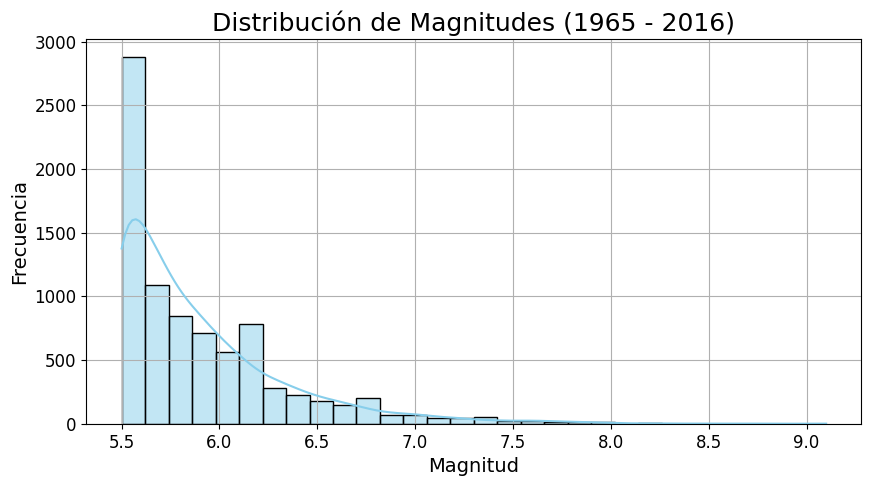

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(df['Magnitude'], bins=30, kde=True, color='skyblue')

plt.title('Distribución de Magnitudes (1965 - 2016)', fontsize=18)
plt.xlabel('Magnitud', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True)
plt.show()

# Magnitudes en el tiempo

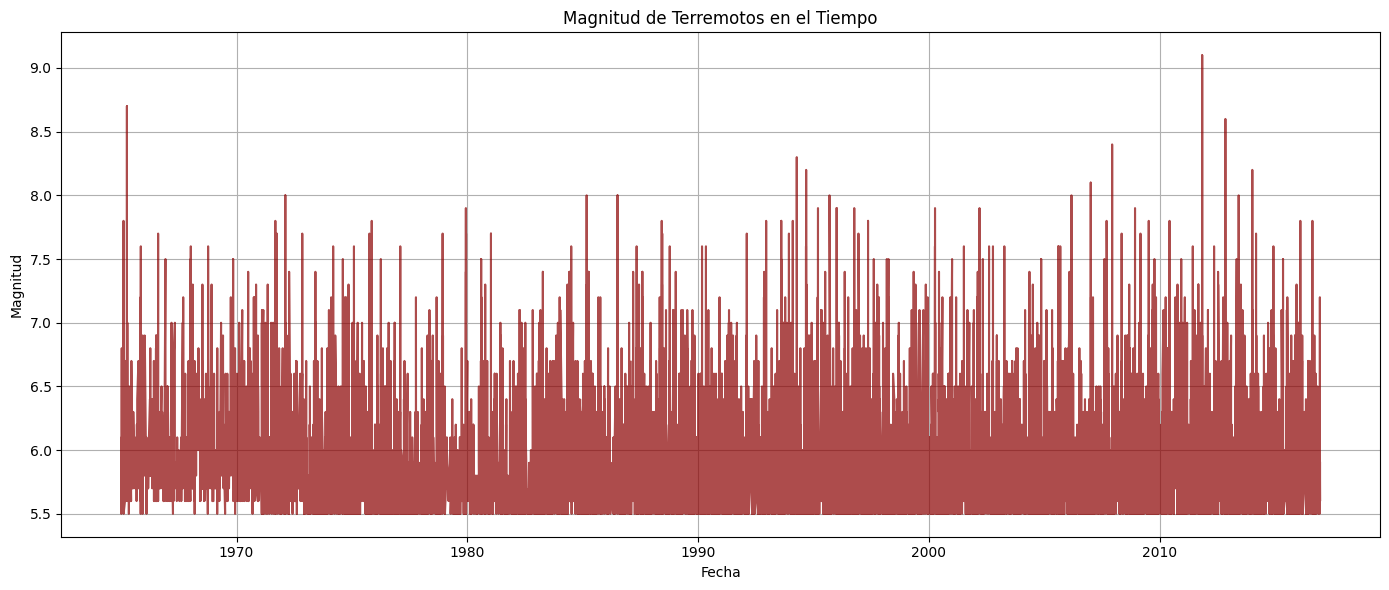

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Magnitude'], color='darkred', alpha=0.7)
plt.title('Magnitud de Terremotos en el Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Magnitud')
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfica por semana

In [ ]:
# Crea las columnas Año-Semana
df['year_week'] = df['Date'].dt.strftime('%Y-%U')
df['week_start'] = df['Date'].dt.to_period('W').dt.start_time

In [ ]:
# Agrupan por semana
df_weekly = df.groupby('week_start')['Magnitude'].mean().reset_index()

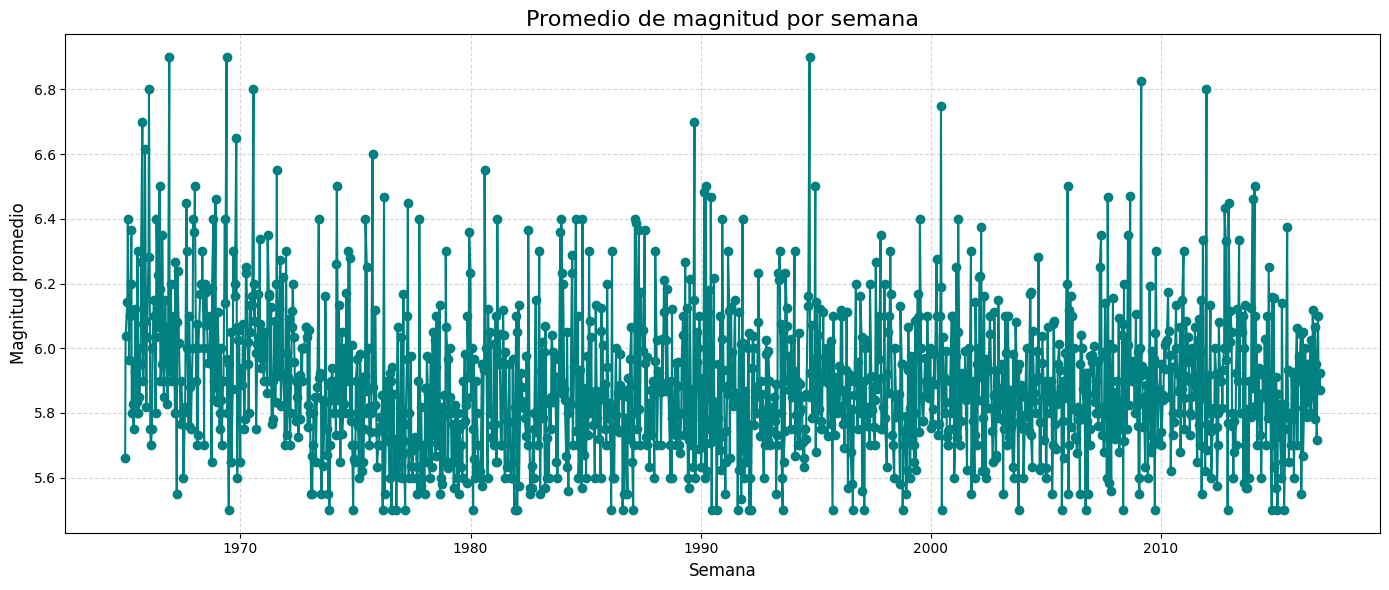

In [ ]:
# Grafica
plt.figure(figsize=(14, 6))
plt.plot(df_weekly['week_start'], df_weekly['Magnitude'], marker='o', linestyle='-', color='teal')
plt.title('Promedio de magnitud por semana', fontsize=16)
plt.xlabel('Semana', fontsize=12)
plt.ylabel('Magnitud promedio', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Gráfico para un día específico

In [ ]:
fecha_input = input("Ingrese una fecha (formato: YYYY-MM-DD): ")

try:
  fecha_dataset = pd.to_datetime(fecha_input)
  df_terremoto = df[df['date_time'].dt.date == fecha_dataset.date()]

  if df_terremoto.empty:
    print("No hay terremotos registrados ese día.")
  else:
    plt.figure(figsize=(12, 5))
    plt.plot(df_terremoto['date_time'], df_terremoto['magnitude'], marker='o', linestyle='-', color='teal')
    plt.fill_between(df_terremoto['date_time'], df_terremoto['magnitude'], color='lightblue', alpha=0.2)
    plt.title(f'Magnitud de Terremotos en {fecha_dataset.date()}')
    plt.xlabel('Fecha')
    plt.ylabel('Magnitud')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
except:
  print("Formato incorrecto. Porfavor inserte la fecha en el formato 'YYYY-MM-DD'.")

Ingrese una fecha (formato: YYYY-MM-DD): 26/02/2015
Formato incorrecto. Porfavor inserte la fecha en el formato 'YYYY-MM-DD'.


/tmp/ipykernel_11062/751977106.py:4: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  fecha_dataset = pd.to_datetime(fecha_input)


In [ ]:
print(df['Date'].sample(5))

3315    1974-02-12
15782   2002-02-04
871     1968-02-03
5631    1980-07-09
8318    1987-06-01
Name: Date, dtype: datetime64[ns]
